In [48]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

from matplotlib.ticker import FormatStrFormatter, AutoMinorLocator

sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
from modules import comoving_density, comoving_density_single_bin

In [49]:
params = {'legend.fontsize': 'x-large',
          'axes.labelsize': 'x-large',
          'axes.titlesize': 'x-large',
          'xtick.labelsize': 'x-large',
          'ytick.labelsize': 'x-large',
          'figure.facecolor': 'w',
          'xtick.top': True,
          'ytick.right': True,
          'xtick.direction': 'in',
          'ytick.direction': 'in',
         }
plt.rcParams.update(params)

In [50]:
# From summary_table.ipynb, in sq. deg.
total_area_north = 4158.0
total_area_south = 9401.3
total_area = total_area_north + total_area_south

--------
# Main

In [51]:
# cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/main_cumulative_lrg.fits'))
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/main_cumulative_lrg.fits'))
cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth
min_depth = 800.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(cat['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# cat = cat[~mask_bad]
# print(len(cat), len(np.unique(cat['TARGETID'])))

# Remove duplidates keeping the higher EFFTIME objects
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))

print(len(cat))

FIBERSTATUS 338266 7165 0.020742203218587794
No data 338265 1 2.9562533627382e-06
LRG mask 304337 33928 0.1003000606033731
Remove QSO targets 299639 4698 0.015436834824553046
Min depth 288287 11352 0.9621144110079128
288287 288260 27
288260 288260 0
288260


In [52]:
# Redshift quality cut
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.5
mask_quality &= cat['DELTACHI2']>15

print(np.sum(~mask_quality)/len(mask_quality))
cat = cat[mask_quality]
print(len(cat))

0.01244362728092694
284673


In [53]:
# Densities from summary_table.ipynb
density = 605.4 * np.sum(mask_quality)/len(mask_quality)
density_north =  603.9 * np.sum(mask_quality)/len(mask_quality)
density_south = 606.0 * np.sum(mask_quality)/len(mask_quality)

In [54]:
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)
cat['SPECTYPE'][mask_star] = 'STAR'
print(np.sum(mask_star)/len(mask_star))

0.004707155227225624


In [55]:
main = cat.copy()

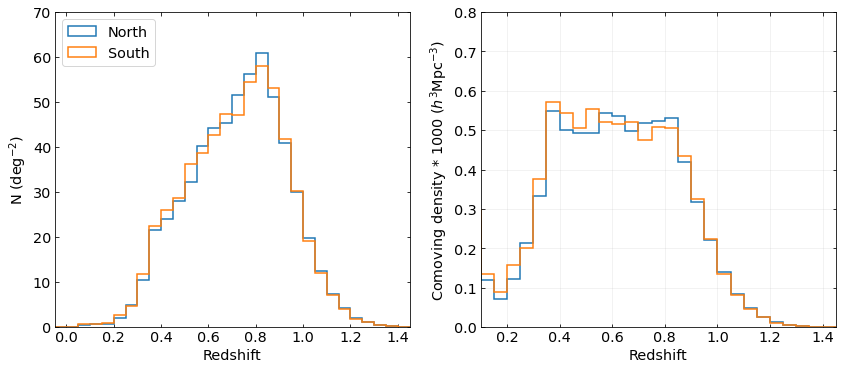

In [56]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'

area = len(cat)/density
area_north = np.sum(mask_north)/density_north
area_south = np.sum(mask_south)/density_south

binsize = 0.05
bins = np.arange(-binsize, 1.55, binsize)
bin_centers = (bins[1:]+bins[:-1])/2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].hist(cat['Z'][mask_north & (~mask_star)], weights=np.ones(int(np.sum(mask_north & (~mask_star))))/area_north,
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
axes[0].hist(cat['Z'][mask_south & (~mask_star)], weights=np.ones(int(np.sum(mask_south & (~mask_star))))/area_south,
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# axes[0].hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('N (deg$^{-2}$)')
axes[0].set_xlim(-0.05, 1.45)
axes[0].set_ylim(0, 70)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
# axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_north], area=area_north, zmin=0., zmax=bins.max(), dz=binsize, axis=[0.1, 1.45, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=False)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_south], area=area_south, zmin=0., zmax=bins.max(), dz=binsize, axis=[0.1, 1.45, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=False)
# plt.legend(loc='lower left')
plt.show()

6.335320618183829e-05
0.0005150509195187636


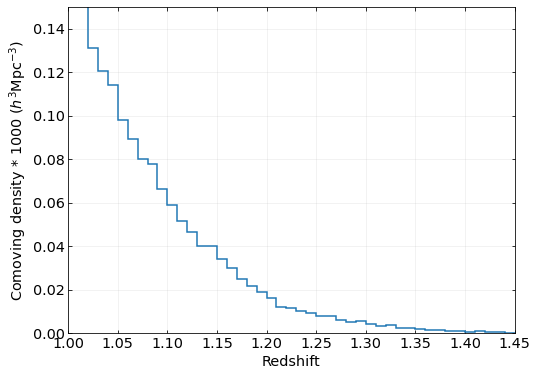

In [57]:
# Kyle asked the comoving number density at z=1.1
zmin = 1.075
zmax = 1.125
mask = (~mask_star) & (cat['Z']>zmin) & (cat['Z']<zmax)
# result in h^3 Mpc^-3
print(comoving_density_single_bin(np.sum(mask), zmin, zmax, area))

# Sanity check for 0.4<z<0.8
zmin = 0.4
zmax = 0.8
mask = (~mask_star) & (cat['Z']>zmin) & (cat['Z']<zmax)
print(comoving_density_single_bin(np.sum(mask), zmin, zmax, area))

plt.figure(figsize=(8, 6))
lrg_plot.plot_comoving_density(cat['Z'], area=area, zmin=0., zmax=bins.max(), dz=0.01, axis=[1., 1.45, 0, 0.15], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=False)

In [58]:
from astropy.cosmology import FlatLambdaCDM

H0=100
Om0=0.3
cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)

# bins_fine = np.arange(-binsize, 1.45, binsize)
shell_volumes = cosmo.comoving_volume(bins[1:]).to_value('Mpc^3')-cosmo.comoving_volume(bins[:-1]).to_value('Mpc^3')
n_plot = 0.5e-3 * shell_volumes / (4*np.pi*(180/np.pi)**2)

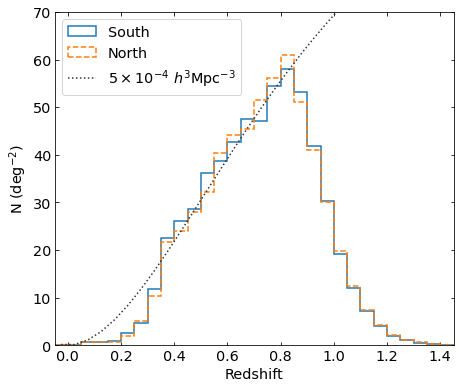

In [59]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
nz_main_north, _, _ = ax.hist(cat['Z'][mask_north & (~mask_star)], weights=np.ones(int(np.sum(mask_north & (~mask_star))))/area_north,
             bins=bins, lw=1.5, histtype='step', label='North', color='C1', ls='--', zorder=2)
nz_main_south, _, _ = ax.hist(cat['Z'][mask_south & (~mask_star)], weights=np.ones(int(np.sum(mask_south & (~mask_star))))/area_south,
             bins=bins, lw=1.5, histtype='step', label='South', color='C0', zorder=1)
ax.plot(bin_centers, n_plot, '0.2', ls=':', label=r'$5\times10^{-4}\ h^3\mathrm{Mpc}^{-3}$')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('N (deg$^{-2}$)')
ax.set_xlim(-0.05, 1.45)
ax.set_ylim(0, 70)
# ax.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dndz.pdf')
plt.show()

In [60]:
# Weighted average of the north+south N(z)
north_weight = total_area_north/area_north
south_weight = total_area_south/area_south
nz_main = (nz_main_north*north_weight + nz_main_south*south_weight) / (north_weight+south_weight)

In [61]:
areas = {'sdss':7900, 'boss':9500, 'eboss':4200}
lrgs = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/lrg_paper/sdss_boss_eboss_lrgs.fits'))

# remove eBOSS LRGs with z<0.45
mask = (lrgs['survey']=='eboss') & (lrgs['Z']<0.45)
lrgs = lrgs[~mask]

In [62]:
# binsize_fine = 0.01
# bins_fine = np.arange(-binsize_fine, 1.55, binsize_fine)
# bin_centers_fine = (bins_fine[1:]+bins_fine[:-1])/2

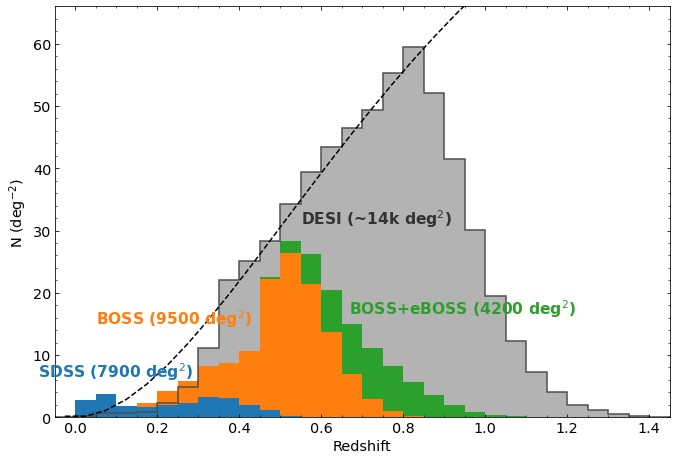

In [63]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))

_, _, _ = ax.hist(bin_centers, weights=nz_main,
             bins=bins, lw=1.5, histtype='bar', label='DESI', color='0.7', ls='--', zorder=0.1)
_, _, _ = ax.hist(bin_centers, weights=nz_main,
             bins=bins, lw=1.5, histtype='step', label='DESI', color='0.3', ls='-', zorder=0.9)


mask = lrgs['survey']=='sdss'
_, _, _ = ax.hist(lrgs['Z'][mask], weights=np.ones(int(np.sum(mask)))/areas['sdss'],
             bins=bins, lw=1.5, histtype='bar', label='SDSS', color='C0', ls='--', zorder=0.5)

mask = lrgs['survey']=='boss'
nz_boss, _, _ = ax.hist(lrgs['Z'][mask], weights=np.ones(int(np.sum(mask)))/areas['boss'],
             bins=bins, lw=1.5, histtype='bar', label='BOSS', color='C1', ls='--', zorder=0.3)

mask = lrgs['survey']=='eboss'
# nz_eboss, _, _ = ax.hist(lrgs['Z'][mask], weights=np.ones(int(np.sum(mask)))/areas['eboss'],
#              bins=bins, lw=1.5, histtype='step', label=None, color=None, ls='--', zorder=0.0)
nz_eboss, _ = np.histogram(lrgs['Z'][mask], weights=np.ones(int(np.sum(mask)))/areas['eboss'],
             bins=bins)

_, _, _ = ax.hist(bin_centers, weights=nz_boss+nz_eboss,
             bins=bins, lw=1.5, histtype='bar', label='eBOSS', color='C2', ls='--', zorder=0.2)

ax.text(0.55, 31, 'DESI (~14k deg$^2$)', fontsize=15.5, color='0.2', fontweight='bold')
ax.text(0.05, 15, 'BOSS (9500 deg$^2$)', fontsize=15.5, color='C1', fontweight='bold')
ax.text(0.668, 16.5, 'BOSS+eBOSS (4200 deg$^2$)', fontsize=15.5, color='C2', fontweight='bold')
ax.text(-0.09, 6.5, 'SDSS (7900 deg$^2$)', fontsize=15.5, color='C0', fontweight='bold')

ax.plot(bin_centers, n_plot, 'k', ls='--', label=r'$5\times10^{-4}\ h^3\mathrm{Mpc}^{-3}$')
handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles[::-1], labels[::-1], loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('N (deg$^{-2}$)')
ax.set_xlim(-0.05, 1.45)
ax.set_ylim(0, 66)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(axis="both", which='both', direction="in", top=True, right=True)
# ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dndz.pdf')
plt.show()

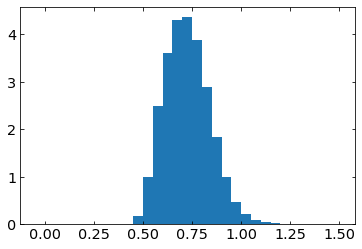

In [64]:
a, b, c = plt.hist(lrgs['Z'][mask], weights=np.ones(int(np.sum(mask)))/areas['sdss'],
                  bins=bins, lw=1.5, histtype='bar', color='C0', ls='--', zorder=0.5,
                  label='SDSS:  7.9k deg$^2$, 195k LRGs')

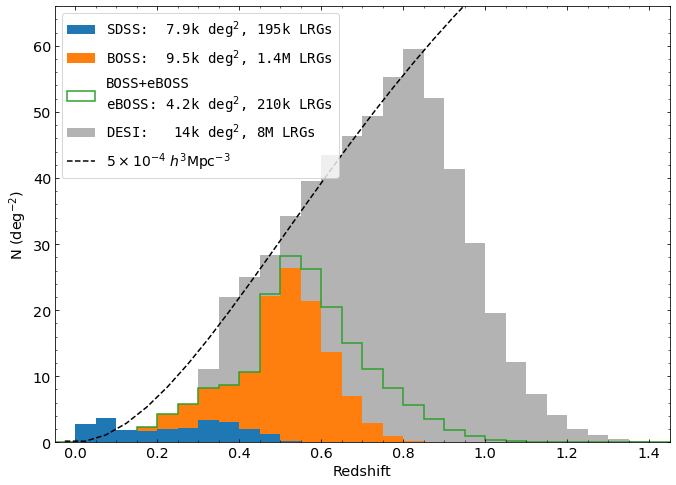

In [65]:
# Save data

zmin, zmax = bins[:-1], bins[1:]
t = Table()
t['zmin'] = zmin
t['zmax'] = zmax
t['zmin'].format = '%.2f'
t['zmax'].format = '%.2f'

fig, ax = plt.subplots(figsize=(9.5, 6.85))

mask = lrgs['survey']=='sdss'
nz_sdss, _, _ = ax.hist(lrgs['Z'][mask], weights=np.ones(int(np.sum(mask)))/areas['sdss'],
                  bins=bins, lw=1.5, histtype='bar', color='C0', ls='--', zorder=0.5,
                  label='SDSS:  7.9k deg$^2$, 195k LRGs')
t['n_sdss_lrg'] = nz_sdss

mask = lrgs['survey']=='boss'
nz_boss, _, _ = ax.hist(lrgs['Z'][mask], weights=np.ones(int(np.sum(mask)))/areas['boss'],
                        bins=bins, lw=1.5, histtype='bar', color='C1', ls='--', zorder=0.3,
                        label='BOSS:  9.5k deg$^2$, 1.4M LRGs')
t['n_boss'] = nz_boss

mask = lrgs['survey']=='eboss'
# nz_eboss, _, _ = ax.hist(lrgs['Z'][mask], weights=np.ones(int(np.sum(mask)))/areas['eboss'],
#              bins=bins, lw=1.5, histtype='step', label=None, color=None, ls='--', zorder=0.0)
nz_eboss, _ = np.histogram(lrgs['Z'][mask], weights=np.ones(int(np.sum(mask)))/areas['eboss'],
                           bins=bins)
_, _, _ = ax.hist(bin_centers, weights=nz_boss+nz_eboss,
                  bins=bins, lw=1.5, histtype='step', color='C2', ls='-', zorder=0.4,
                  label='BOSS+eBOSS\neBOSS: 4.2k deg$^2$, 210k LRGs')
t['n_boss_plus_eboss'] = nz_boss + nz_eboss

_, _, _ = ax.hist(bin_centers, weights=nz_main,
                  bins=bins, lw=1.5, histtype='bar', color='0.7', ls='--', zorder=0.1,
                  label='DESI:   14k deg$^2$, 8M LRGs')
# _, _, _ = ax.hist(bin_centers, weights=nz_main,
#                   bins=bins, lw=1.5, histtype='step', color='0.3', ls='-', zorder=0.9)

t['n_desi_lrg'] = nz_main
t.write('zenodo/fig_1_histograms.csv', overwrite=True)

ax.plot(bin_centers, n_plot, 'k', ls='--', label=r'$5\times10^{-4}\ h^3\mathrm{Mpc}^{-3}$')
t = Table()
t['z'] = zmin
t['N'] = n_plot
t.write('zenodo/fig_1_const_comoving_density.csv', overwrite=True)

# ax.text(0.55, 31, 'DESI: ~14k deg$^2$, 8M redshifts', fontsize=15.5, color='0.2', fontweight='bold')
# ax.text(0.05, 15, 'BOSS: 9500 deg$^2$\n, 1.4M redshifts', fontsize=15.5, color='C1', fontweight='bold')
# ax.text(0.668, 16.5, 'BOSS+eBOSS: 4200 deg$^2$,\n210k redshifts in eBOSS', fontsize=15.5, color='C2', fontweight='bold')
# ax.text(-0.09, 6.5, 'SDSS: 7900 deg$^2$,\n200k redshifts', fontsize=15.5, color='C0', fontweight='bold')

handles, labels = ax.get_legend_handles_labels()
order = [1, 2, 3, 4, 0]
import matplotlib.font_manager as font_manager
font = font_manager.FontProperties(family='monospace', size=14, style='normal')
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc='upper left', prop=font)
# ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('N (deg$^{-2}$)')
ax.set_xlim(-0.05, 1.45)
ax.set_ylim(0, 66)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(axis="both", which='both', direction="in", top=True, right=True)
# ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dndz_1.pdf')
plt.show()

In [66]:
binsize_txt = 0.01
bins_txt = np.arange(0, 1.42, binsize_txt)

# surface density
surf_density_north = np.histogram(cat['Z'][mask_north & (~mask_star)], weights=np.ones(int(np.sum(mask_north & (~mask_star))))/area_north, bins=bins_txt)[0]
surf_density_south = np.histogram(cat['Z'][mask_south & (~mask_star)], weights=np.ones(int(np.sum(mask_south & (~mask_star))))/area_south, bins=bins_txt)[0]

t = Table()
t['zmin'] = bins_txt[:-1]
t['zmax'] = bins_txt[1:]
t['zmin'].format = '%.2f'
t['zmax'].format = '%.2f'
t['N_all'] = (surf_density_north*north_weight + surf_density_south*south_weight) / (north_weight+south_weight)
t['N_all'].format = '%.2f'
t['N_north'] = surf_density_north
t['N_north'].format = '%.2f'
t['N_south'] = surf_density_south
t['N_south'].format = '%.2f'
t.write('data/main_lrg_dndz.txt', format='ascii.commented_header', 
       formats={'zmin':'%4.2f', 'zmax':'%4.2f', 'N_all':'%.7g', 'N_north':'%.7g', 'N_south':'%.7g'},
       overwrite=True)
t

zmin,zmax,N_all,N_north,N_south
float64,float64,float64,float64,float64
0.00,0.01,0.00,0.00,0.00
0.01,0.02,0.01,0.01,0.01
0.02,0.03,0.01,0.01,0.02
0.03,0.04,0.06,0.07,0.05
0.04,0.05,0.06,0.07,0.05
0.05,0.06,0.12,0.14,0.10
0.06,0.07,0.09,0.09,0.09
0.07,0.08,0.12,0.12,0.13
0.08,0.09,0.18,0.16,0.20


In [67]:
print(t['N_all'].sum())
print(t['N_north'].sum())
print(t['N_south'].sum())

594.6671125879554
594.1760562412109
595.1529423380296


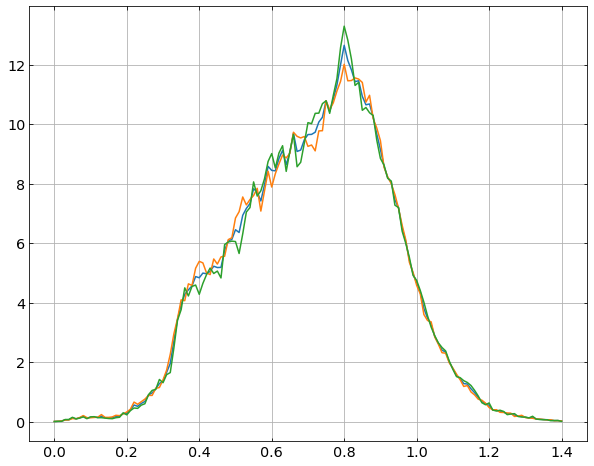

In [68]:
tt = Table.read('/Users/rongpu/git/desi-targets/lrg_paper/data/main_lrg_dndz.txt', format='ascii.commented_header')

plt.figure(figsize=(10, 8))
plt.plot(bins_txt[:-1], tt['N_all'])
plt.plot(bins_txt[:-1], tt['N_south'])
plt.plot(bins_txt[:-1], tt['N_north'])
plt.grid()
plt.show()

In [69]:
# For Christophe with dz=0.05 
binsize_txt = 0.05
bins_txt = np.arange(0, 1.42, binsize_txt)

# surface density
surf_density_north = np.histogram(cat['Z'][mask_north & (~mask_star)], weights=np.ones(int(np.sum(mask_north & (~mask_star))))/area_north, bins=bins_txt)[0]
surf_density_south = np.histogram(cat['Z'][mask_south & (~mask_star)], weights=np.ones(int(np.sum(mask_south & (~mask_star))))/area_south, bins=bins_txt)[0]

t = Table()
t['zmin'] = bins_txt[:-1]
t['zmax'] = bins_txt[1:]
t['zmin'].format = '%.2f'
t['zmax'].format = '%.2f'
t['surface_density'] = (surf_density_north*north_weight + surf_density_south*south_weight) / (north_weight+south_weight)
t['surface_density'].format = '%.2f'
t['comoving_density'] = 0.
for index in range(len(t)):
    shell_volume = cosmo.comoving_volume(t['zmax'][index]).to_value('Mpc^3')-cosmo.comoving_volume(t['zmin'][index]).to_value('Mpc^3')
    t['comoving_density'][index] = t['surface_density'][index] * (4*np.pi*(180/np.pi)**2) / shell_volume
t['comoving_density'].format = '%.7f'
t.write('data/main_lrg_dndz_for_christophe.txt', format='ascii.commented_header', 
       formats={'zmin':'%4.2f', 'zmax':'%4.2f', 'surface_density':'%.7g'},
       overwrite=True)
print('surface density in (deg^-2)')
print('comoving density in (h^3 Mpc^-3)')
t

surface density in (deg^-2)
comoving density in (h^3 Mpc^-3)


zmin,zmax,surface_density,comoving_density
float64,float64,float64,float64
0.00,0.05,0.14,0.0004331
0.05,0.10,0.63,0.0002831
0.10,0.15,0.74,0.0001284
0.15,0.20,0.86,0.0000805
0.20,0.25,2.34,0.0001399
0.25,0.30,4.91,0.0002073
0.30,0.35,11.10,0.0003548
0.35,0.40,22.06,0.0005593
0.40,0.45,25.06,0.0005229


594.6530392251286


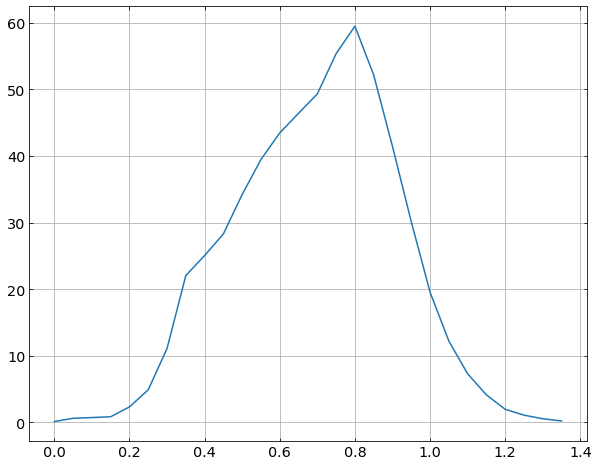

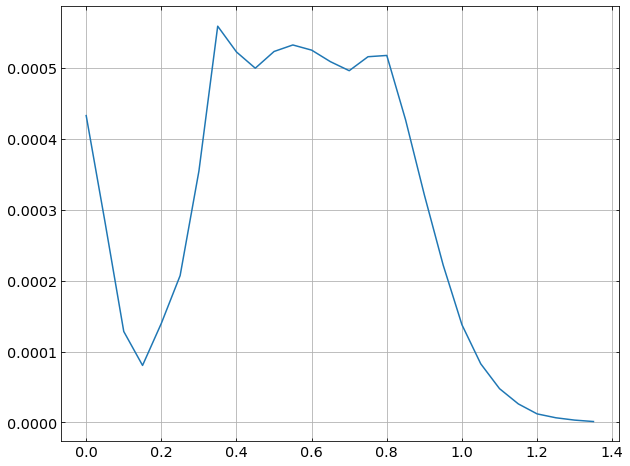

In [70]:
print(t['surface_density'].sum())

tt = Table.read('/Users/rongpu/git/desi-targets/lrg_paper/data/main_lrg_dndz_for_christophe.txt', format='ascii.commented_header')

plt.figure(figsize=(10, 8))
plt.plot(bins_txt[:-1], tt['surface_density'])
plt.grid()
plt.show()

plt.figure(figsize=(10, 8))
plt.plot(bins_txt[:-1], tt['comoving_density'])
plt.grid()
plt.show()

In [71]:
# For Kyle with dz=0.1
binsize_txt = 0.1
bins_txt = np.arange(0, 1.42, binsize_txt)

# surface density
surf_density_north = np.histogram(cat['Z'][mask_north & (~mask_star)], weights=np.ones(int(np.sum(mask_north & (~mask_star))))/area_north, bins=bins_txt)[0]
surf_density_south = np.histogram(cat['Z'][mask_south & (~mask_star)], weights=np.ones(int(np.sum(mask_south & (~mask_star))))/area_south, bins=bins_txt)[0]

t = Table()
t['zmin'] = bins_txt[:-1]
t['zmax'] = bins_txt[1:]
t['zmin'].format = '%.2f'
t['zmax'].format = '%.2f'
t['surface_density'] = (surf_density_north*north_weight + surf_density_south*south_weight) / (north_weight+south_weight)
t['surface_density'].format = '%.2f'
t['comoving_density'] = 0.
for index in range(len(t)):
    shell_volume = cosmo.comoving_volume(t['zmax'][index]).to_value('Mpc^3')-cosmo.comoving_volume(t['zmin'][index]).to_value('Mpc^3')
    t['comoving_density'][index] = t['surface_density'][index] * (4*np.pi*(180/np.pi)**2) / shell_volume
t['comoving_density'].format = '%.7f'
t.write('data/main_lrg_dndz_for_kyle.txt', format='ascii.commented_header', 
       formats={'zmin':'%4.2f', 'zmax':'%4.2f', 'surface_density':'%.7g'},
       overwrite=True)
print('surface density in (deg^-2)')
print('comoving density in (h^3 Mpc^-3)')
t

surface density in (deg^-2)
comoving density in (h^3 Mpc^-3)


zmin,zmax,surface_density,comoving_density
float64,float64,float64,float64
0.00,0.10,0.77,0.0003025
0.10,0.20,1.60,0.0000973
0.20,0.30,7.24,0.0001794
0.30,0.40,33.16,0.0004688
0.40,0.50,53.36,0.0005105
0.50,0.60,73.70,0.0005285
0.60,0.70,89.87,0.0005170
0.70,0.80,104.68,0.0005068
0.80,0.90,111.63,0.0004712


594.6530392251285


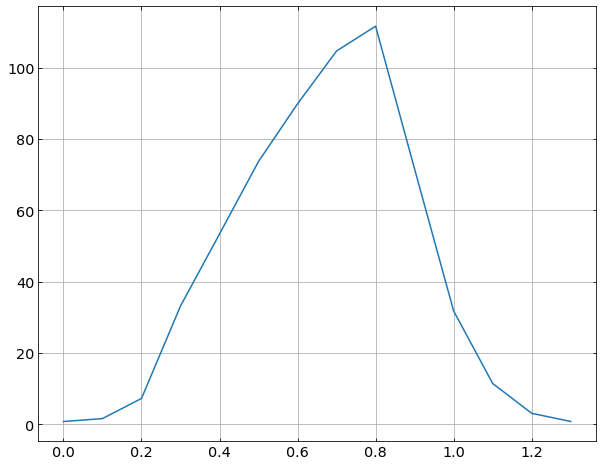

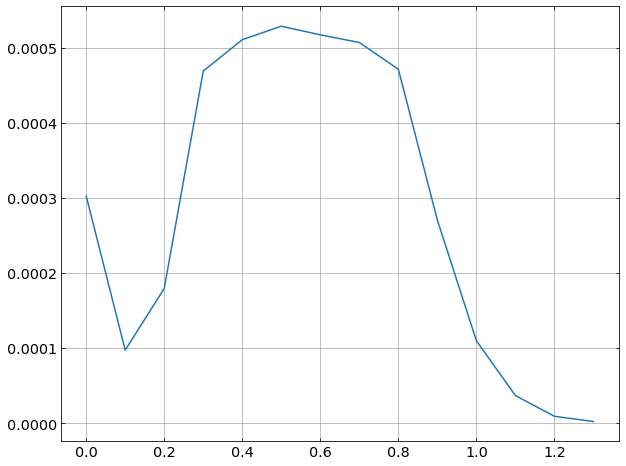

In [72]:
print(t['surface_density'].sum())

tt = Table.read('/Users/rongpu/git/desi-targets/lrg_paper/data/main_lrg_dndz_for_kyle.txt', format='ascii.commented_header')

plt.figure(figsize=(10, 8))
plt.plot(bins_txt[:-1], tt['surface_density'])
plt.grid()
plt.show()

plt.figure(figsize=(10, 8))
plt.plot(bins_txt[:-1], tt['comoving_density'])
plt.grid()
plt.show()

--------
# SV3

In [73]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv3_cumulative_lrg.fits'))
cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth
min_depth = 800.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(cat['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# cat = cat[~mask_bad]
# print(len(cat), len(np.unique(cat['TARGETID'])))

# Remove duplidates keeping the higher EFFTIME objects
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))

print(len(cat))

FIBERSTATUS 164618 18004 0.09858615062807329
No data 164614 4 2.4298679366776417e-05
LRG mask 150726 13888 0.08436706476970367
Remove QSO targets 150726 0 0.0
Min depth 149567 1159 0.9923105502700265
149567 127328 22239
127328 127328 0
127328


In [74]:
# Redshift quality cut
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.5
mask_quality &= cat['DELTACHI2']>15

print(np.sum(~mask_quality)/len(mask_quality))
cat = cat[mask_quality]
print(len(cat))

0.010963810002513194
125932


In [75]:
# Densities from target_densities.ipynb
density = 805.83 * np.sum(mask_quality)/len(mask_quality)
density_north =  807.29 * np.sum(mask_quality)/len(mask_quality)
density_south = 805.14 * np.sum(mask_quality)/len(mask_quality)

In [76]:
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)
cat['SPECTYPE'][mask_star] = 'STAR'
print(np.sum(mask_star)/len(mask_star))

0.002120191849569609


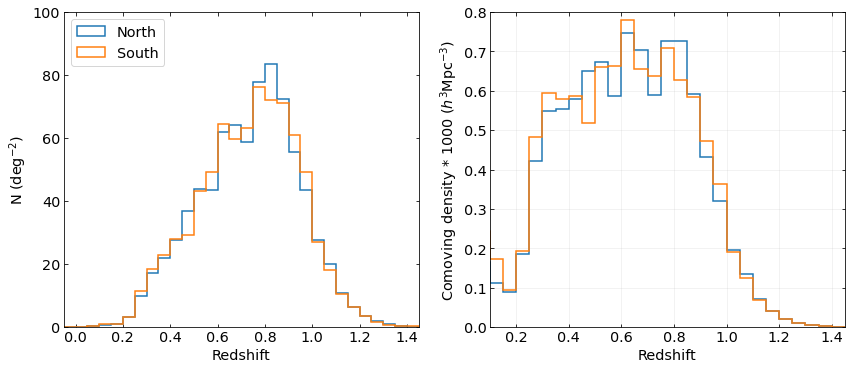

In [77]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'

area = len(cat)/density
area_north = np.sum(mask_north)/density_north
area_south = np.sum(mask_south)/density_south

# binsize = 0.05
# bins = np.arange(-binsize, 1.55, binsize)
# bin_centers = (bins[1:]+bins[:-1])/2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].hist(cat['Z'][mask_north & (~mask_star)], weights=np.ones(int(np.sum(mask_north & (~mask_star))))/area_north,
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
axes[0].hist(cat['Z'][mask_south & (~mask_star)], weights=np.ones(int(np.sum(mask_south & (~mask_star))))/area_south,
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# axes[0].hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('N (deg$^{-2}$)')
axes[0].set_xlim(-0.05, 1.45)
axes[0].set_ylim(0, 100)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
# axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_north], area=area_north, zmin=0., zmax=bins.max(), dz=binsize, axis=[0.1, 1.45, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=False)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_south], area=area_south, zmin=0., zmax=bins.max(), dz=binsize, axis=[0.1, 1.45, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=False)
# plt.legend(loc='lower left')
plt.show()

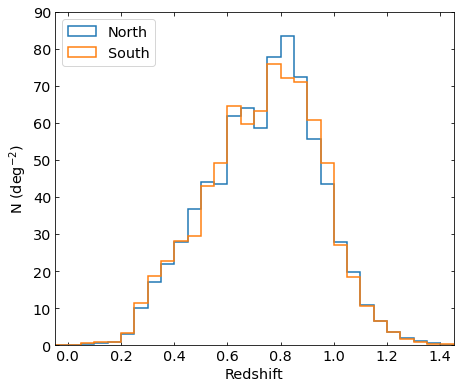

In [78]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
nz_sv3_north, _, _ = ax.hist(cat['Z'][mask_north & (~mask_star)], weights=np.ones(int(np.sum(mask_north & (~mask_star))))/area_north,
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
nz_sv3_south, _, _ = ax.hist(cat['Z'][mask_south & (~mask_star)], weights=np.ones(int(np.sum(mask_south & (~mask_star))))/area_south,
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# ax.plot(bin_centers, n_plot, '0.7', ls='--')
# ax.hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('N (deg$^{-2}$)')
ax.set_xlim(-0.05, 1.45)
ax.set_ylim(0, 90)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
# ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/more/sv3_dndz.pdf')
plt.show()

In [79]:
sv3 = cat.copy()

--------
# SV1

In [80]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_cumulative_lrg.fits'))
cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth
min_depth = 2000.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(cat['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# cat = cat[~mask_bad]
# print(len(cat), len(np.unique(cat['TARGETID'])))

# ZWARN
mask = cat['ZWARN']==0
print('ZWARN', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove duplidates keeping the higher EFFTIME objects
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))

print(len(cat))

FIBERSTATUS 46319 8916 0.16141938987960533
No data 46312 7 0.0001511258878645912
LRG mask 42117 4195 0.09058127483157713
Remove QSO targets 42117 0 0.0
Min depth 36183 5934 0.8591067739867512
ZWARN 35929 254 0.007019871210236852
35929 35861 68
35861 35861 0
35861


In [81]:
# Redshift quality cut
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.5
mask_quality &= cat['DELTACHI2']>15

print(np.sum(~mask_quality)/len(mask_quality))
cat = cat[mask_quality]
print(len(cat))

0.00797523772343214
35575


In [82]:
# Densities from target_densities.ipynb
density = 2124.72 * np.sum(mask_quality)/len(mask_quality)
density_north =  2123.03 * np.sum(mask_quality)/len(mask_quality)
density_south = 2125.53 * np.sum(mask_quality)/len(mask_quality)

In [83]:
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)
cat['SPECTYPE'][mask_star] = 'STAR'
print(np.sum(mask_star)/len(mask_star))

0.011553056921995784


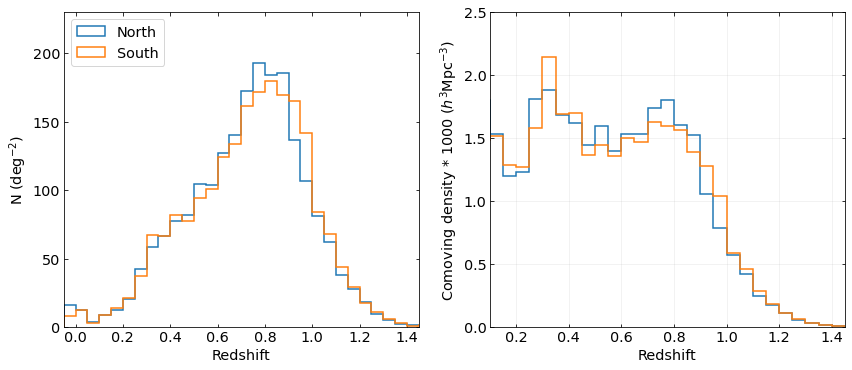

In [84]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'

area = len(cat)/density
area_north = np.sum(mask_north)/density_north
area_south = np.sum(mask_south)/density_south

# binsize = 0.05
# bins = np.arange(-binsize, 1.55, binsize)
# bin_centers = (bins[1:]+bins[:-1])/2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].hist(cat['Z'][mask_north], weights=np.ones(int(np.sum(mask_north)))/area_north,
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
axes[0].hist(cat['Z'][mask_south], weights=np.ones(int(np.sum(mask_south)))/area_south,
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# axes[0].hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('N (deg$^{-2}$)')
axes[0].set_xlim(-0.05, 1.45)
axes[0].set_ylim(0, 230)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
# axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_north], area=area_north, zmin=0., zmax=bins.max(), dz=binsize, axis=[0.1, 1.45, 0, 2.5], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=False)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_south], area=area_south, zmin=0., zmax=bins.max(), dz=binsize, axis=[0.1, 1.45, 0, 2.5], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=False)
# plt.legend(loc='lower left')
plt.show()

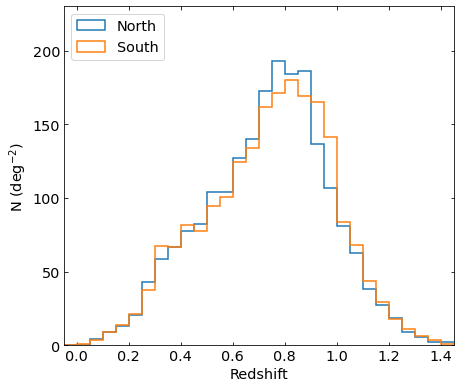

In [85]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
nz_sv1_north, _, _ = ax.hist(cat['Z'][mask_north & (~mask_star)], weights=np.ones(int(np.sum(mask_north & (~mask_star))))/area_north,
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
nz_sv1_south, _, _ = ax.hist(cat['Z'][mask_south & (~mask_star)], weights=np.ones(int(np.sum(mask_south & (~mask_star))))/area_south,
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# ax.plot(bin_centers, n_plot, '0.7', ls='--')
# ax.hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('N (deg$^{-2}$)')
ax.set_xlim(-0.05, 1.45)
ax.set_ylim(0, 230)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
# ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/more/sv1_dndz.pdf')
plt.show()

"SV1 bright" density
1403.5310791404931
1402.7745317533106


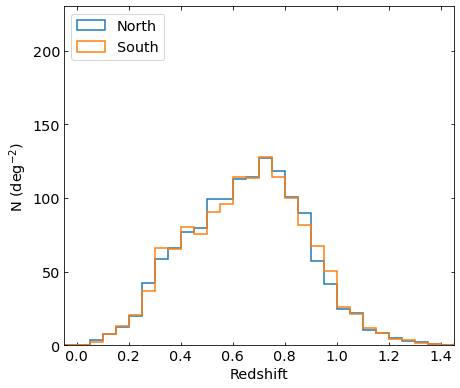

In [86]:
cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

# Apply the Main Survey zfibermag cut
mask_zfiber_north = cat['zfibermag']<21.61
mask_zfiber_south = cat['zfibermag']<21.60

print("\"SV1 bright\" density")
print(np.sum(mask_north & (~mask_star) & mask_zfiber_north)/area_north)
print(np.sum(mask_south & (~mask_star) & mask_zfiber_south)/area_south)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
nz_sv1_north_zfiber, _, _ = ax.hist(cat['Z'][mask_north & (~mask_star) & mask_zfiber_north], weights=np.ones(int(np.sum(mask_north & (~mask_star) & mask_zfiber_north)))/area_north,
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
nz_sv1_south_zfiber, _, _ = ax.hist(cat['Z'][mask_south & (~mask_star) & mask_zfiber_south], weights=np.ones(int(np.sum(mask_south & (~mask_star) & mask_zfiber_south)))/area_south,
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# ax.plot(bin_centers, n_plot, '0.7', ls='--')
# ax.hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('N (deg$^{-2}$)')
ax.set_xlim(-0.05, 1.45)
ax.set_ylim(0, 230)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
# ax.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/more/sv1_dndz.pdf')
plt.show()

In [87]:
sv1 = cat.copy()

-------
# N(z) of all LRG samples

In [88]:
t.write('zenodo/fig_16_main_north.txt',
        format='ascii.commented_header', 
       formats={'zmin':'%4.2f', 'zmax':'%4.2f'}, overwrite=True)

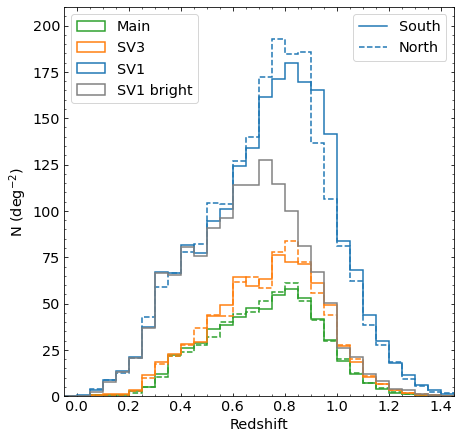

In [89]:
# Save data

zmin, zmax = bins[:-1], bins[1:]
t = Table()
t['zmin'] = zmin
t['zmax'] = zmax
t['zmin'].format = '%.2f'
t['zmax'].format = '%.2f'

fig, ax = plt.subplots(figsize=(6.5, 6.2))
_, _, _ = ax.hist(bin_centers, weights=nz_main_south,
             bins=bins, lw=1.5, histtype='step', label='Main', color='C2')
t['n_main_south'] = nz_main_south

ax.hist(bin_centers, weights=nz_main_north,
             bins=bins, lw=1.5, histtype='step', label=None, color='C2', ls='--')
t['n_main_north'] = nz_main_north

p2 = ax.hist(bin_centers, weights=nz_sv3_south,
             bins=bins, lw=1.5, histtype='step', label='SV3', color='C1')
t['n_sv3_south'] = nz_sv3_south
ax.hist(bin_centers, weights=nz_sv3_north,
             bins=bins, lw=1.5, histtype='step', label=None, color='C1', ls='--')
t['n_sv3_north'] = nz_sv3_north

_, _, p1 = ax.hist(bin_centers, weights=nz_sv1_south,
             bins=bins, lw=1.5, histtype='step', label='SV1', color='C0')
t['n_sv1_south'] = nz_sv1_south

ax.hist(bin_centers, weights=nz_sv1_north,
             bins=bins, lw=1.5, histtype='step', label=None, color='C0', ls='--')
t['n_sv1_north'] = nz_sv1_north

_, _, p1 = ax.hist(bin_centers, weights=nz_sv1_south_zfiber,
             bins=bins, lw=1.5, histtype='step', label='SV1 bright', color='0.5')
t['n_sv1_bright'] = nz_sv1_south_zfiber

t.write('zenodo/fig_16.csv', overwrite=True)

# ax.hist(bin_centers, weights=nz_sv1_north_zfiber,
#              bins=bins, lw=1.5, histtype='step', label=None, color='0.7', ls='--')
# ax.plot(bin_centers, n_plot, '0.7', ls='--')
# ax.hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
leg1 = ax.legend(loc='upper left')
p1, = ax.plot([1,2], [-1,-2], ls='-', color='C0')
p2, = ax.plot([1,2], [-1,-2], ls='--', color='C0')
leg2 = ax.legend([p1, p2], ['South', 'North'], loc='upper right')
ax.add_artist(leg1)
# ax.legend([p1, p2, p3], loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('N (deg$^{-2}$)')
ax.set_xlim(-0.05, 1.45)
ax.set_ylim(0, 210)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
# ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/all_lrgs_dndz.pdf')
plt.show()

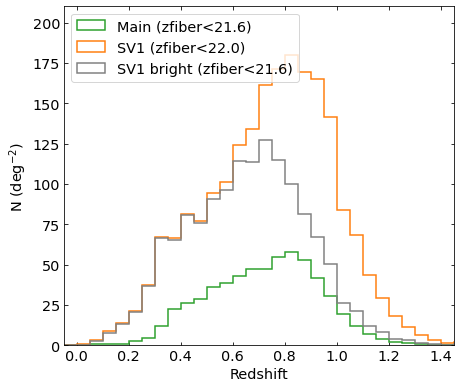

In [90]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.hist(bin_centers, weights=nz_main_south,
             bins=bins, lw=1.5, histtype='step', label='Main (zfiber<21.6)', color='C2')
_, _, p1 = ax.hist(bin_centers, weights=nz_sv1_south,
             bins=bins, lw=1.5, histtype='step', label='SV1 (zfiber<22.0)', color='C1')
_, _, p1 = ax.hist(bin_centers, weights=nz_sv1_south_zfiber,
             bins=bins, lw=1.5, histtype='step', label='SV1 bright (zfiber<21.6)', color='0.5')
# ax.hist(bin_centers, weights=nz_sv1_north_zfiber,
#              bins=bins, lw=1.5, histtype='step', label=None, color='0.7', ls='--')
# ax.plot(bin_centers, n_plot, '0.7', ls='--')
# ax.hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
leg1 = ax.legend(loc='upper left')
# p1, = ax.plot([1,2], [-1,-2], ls='-', color='k')
# p2, = ax.plot([1,2], [-1,-2], ls='--', color='k')
# leg2 = ax.legend([p1, p2], ['South', 'North'], loc='upper right')
# ax.add_artist(leg1)
# ax.legend([p1, p2, p3], loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('N (deg$^{-2}$)')
ax.set_xlim(-0.05, 1.45)
ax.set_ylim(0, 210)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
# ax.grid(alpha=0.5)
plt.tight_layout()
plt.show()

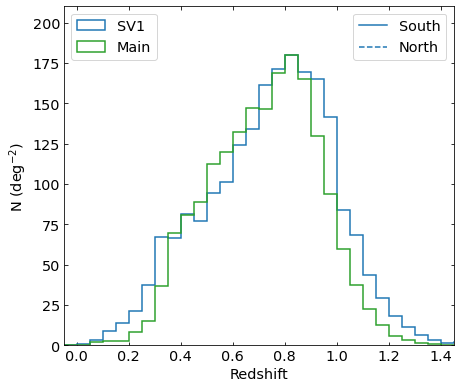

In [91]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
_, _, p1 = ax.hist(bin_centers, weights=nz_sv1_south,
             bins=bins, lw=1.5, histtype='step', label='SV1', color='C0')
ax.hist(bin_centers, weights=nz_main_south*3.1,
             bins=bins, lw=1.5, histtype='step', label='Main', color='C2')
# ax.plot(bin_centers, n_plot, '0.7', ls='--')
# ax.hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
leg1 = ax.legend(loc='upper left')
p1, = ax.plot([1,2], [-1,-2], ls='-', color='C0')
p2, = ax.plot([1,2], [-1,-2], ls='--', color='C0')
leg2 = ax.legend([p1, p2], ['South', 'North'], loc='upper right')
ax.add_artist(leg1)
# ax.legend([p1, p2, p3], loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('N (deg$^{-2}$)')
ax.set_xlim(-0.05, 1.45)
ax.set_ylim(0, 210)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
# ax.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/all_lrgs_dndz.pdf')
plt.show()

-------

In [92]:
# fig, ax = plt.subplots(figsize=(16, 6))
# ax.plot(sv1['TARGET_RA'], np.sin(np.radians(sv1['TARGET_DEC'])), '.', ms=0.2, alpha=1, label='SV1', zorder=1)
# ax.plot(sv3['TARGET_RA'], np.sin(np.radians(sv3['TARGET_DEC'])), '.', ms=0.2, alpha=1, label='SV3', zorder=2)
# ax.plot(main['TARGET_RA'], np.sin(np.radians(main['TARGET_DEC'])), '.', color='0.7', ms=.2, alpha=1, label='Main survey', zorder=0)
# ax.set_xlabel('RA (deg)')
# ax.set_ylabel('DEC (deg)')
# ax.set_yticks(np.sin(np.radians(np.arange(-70, 90, 20))))
# ax.set_yticklabels(np.arange(-70, 90, 20))
# ax.set_xticks(np.arange(0, 361, 30))
# ax.axis([360, 0, -0.5, 1.])
# ax.grid(alpha=0.5)
# plt.legend(markerscale=30)
# plt.tight_layout()
# # plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/observed_lrgs_radec.png')
# plt.show()

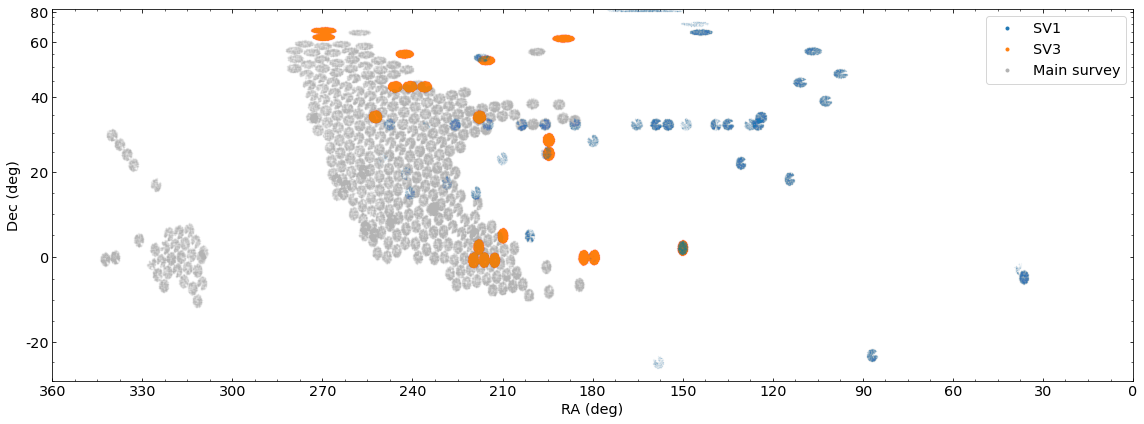

In [93]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(sv1['TARGET_RA'], np.sin(np.radians(sv1['TARGET_DEC'])), 'C0.', ms=0.2, alpha=0.2, zorder=2)
ax.plot(-99, -99, '.', ms=0.2, alpha=1, label='SV1', zorder=1)
ax.plot(sv3['TARGET_RA'], np.sin(np.radians(sv3['TARGET_DEC'])), 'C1.', ms=0.2, alpha=0.2, zorder=1)
ax.plot(-99, -99, '.', ms=0.2, alpha=1, label='SV3', zorder=2)
ax.plot(main['TARGET_RA'], np.sin(np.radians(main['TARGET_DEC'])), '.', color='0.7', ms=.2, alpha=0.2, zorder=0)
ax.plot(-99, -99, '.', color='0.7', ms=.2, alpha=1, label='Main survey', zorder=0)
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
ax.set_yticks(np.sin(np.radians(np.arange(-80, 81, 20))))
ax.set_yticks(np.sin(np.radians(np.arange(-80, 85, 5))), minor=True)
ax.set_yticklabels(np.arange(-80, 81, 20))
ax.set_xticks(np.arange(0, 361, 30))
ax.axis([360, 0, -0.5, 1.])
ax.xaxis.set_minor_locator(AutoMinorLocator())
# ax.yaxis.set_minor_locator(AutoMinorLocator())
# ax.grid(alpha=0.5)
plt.legend(markerscale=30)
plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/observed_lrgs_radec.png')
plt.show()

################################################################################################

fits = fitsio.FITS('zenodo/fig_7.fits','rw')

t = sv1[['TARGET_RA', 'TARGET_DEC']].copy()
fits.write(dict(t), extname='SV1')

t = sv3[['TARGET_RA', 'TARGET_DEC']].copy()
fits.write(dict(t), extname='SV3')

t = main[['TARGET_RA', 'TARGET_DEC']].copy()
fits.write(dict(t), extname='MAIN')

fits.close()

In [94]:
fitsio.FITS('zenodo/fig_7.fits')


  file: zenodo/fig_7.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      SV1
  2      BINARY_TBL      SV3
  3      BINARY_TBL      MAIN

In [95]:
Table(fitsio.read('zenodo/fig_7.fits', ext=3))

TARGET_RA,TARGET_DEC
float64,float64
311.52996778091364,-11.648768173360539
311.62323379306605,-11.651526451283537
311.74727637744314,-11.64107556905128
311.96638255756454,-11.64036700023392
312.0969499527197,-11.67970731040828
310.9442603348904,-11.445472142570043
310.99387385807336,-11.479065762637328
311.01934096446774,-11.507878766947401
311.0654921385534,-11.54044081281937
